<a href="https://colab.research.google.com/github/LuisFelipeVelasco/ML_And_Generative_AI_Experiments/blob/main/Notebooks/neural_network_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **NEURAL NETWORK FROM SCRATCH**

**IMPORT LIBRARIES**

In [1]:
import numpy as np
import pandas as pd

**DEFINE CLASS**

In [113]:
class NeuralNetwork():

  """Representation of a neural network"""

  def __init__(self, learning_rate:int, layers:list, epochs:int):

    """Initialize the neural network"""

    self.learning_rate = learning_rate
    self.layers = layers
    self.epochs = epochs
    self.count_layers =len(layers)

  def initialize_weights(self ,input_size:int):

    """Initialize the weights of the neural network with random numbers between 1 and 0"""

    self.weights = []
    for current_layer in range(self.count_layers):
      layer_size = self.layers[current_layer]
      if current_layer == 0:
        shape=(layer_size, input_size)
        self.weights.append(np.random.random_sample(shape))
      else:
        layer_before = current_layer-1
        layer_before_size = self.layers[layer_before]
        shape=(layer_size ,layer_before_size)
        self.weights.append(np.random.randn(*shape) *0.01)

  def initialize_biases(self):

    """Initialize the biases of the neural network with random numbers between 1 and 0"""

    self.biases=[]
    for current_layer in range(self.count_layers):
      layer_size = self.layers[current_layer]
      shape=(layer_size,1)
      self.biases.append(np.zeros(shape))

  def get_activation(self,z):

    """Get the activation of the net input of a neural network"""

    return 1/(1+np.exp(-z))

  def get_layer_activations(self,sample_features):

    """Get the activation of the neurons of the neural network"""

    current_activations = sample_features
    layer_activations = []
    for current_layer in range(self.count_layers):
      current_activations= self.get_activation((self.weights[current_layer] @ current_activations)+self.biases[current_layer])
      layer_activations.append(current_activations)
    return layer_activations

  def backpropagation(self,layer_activations, sample, prediction_error):

    """Calculate the gradient of the weights and biases"""

    weights_gradients=[]
    biases_gradients=[]
    last_layer=self.count_layers-1
    first_layer=0
    for current_layer in range(last_layer,-1,-1):
      layer_activation= layer_activations[current_layer]
      activation_derivative = layer_activation*(1-layer_activation)
      if(current_layer == last_layer):cost_derivative =-1*prediction_error
      else: cost_derivative = np.transpose(self.weights[current_layer+1]) @ layer_errors
      layer_errors=cost_derivative * activation_derivative
      if(current_layer==first_layer): input_layer= np.transpose(sample)
      else:input_layer= np.transpose(layer_activations[current_layer-1])
      weights_derivative = layer_errors @ input_layer
      biases_derivative=layer_errors
      weights_gradients.insert(0,weights_derivative)
      biases_gradients.insert(0,biases_derivative)

    return weights_gradients, biases_gradients


  def optimization(self,weights_gradients,biases_gradients):

    "update the weights and the biases of the neural network to minimize the cost using gradient descent"

    for current_layer in range(self.count_layers):
      self.weights[current_layer] += -1*self.learning_rate*weights_gradients[current_layer]
      self.biases[current_layer] += -1*self.learning_rate*biases_gradients[current_layer]

  def fit(self, samples,labels):

    """Train neural network"""

    count_samples = samples.shape[0]
    count_features= samples.shape[1]
    self.initialize_weights(count_features)
    self.initialize_biases()
    for i in range (self.epochs):
      self.cost = 0;
      for j in range (count_samples):
        sample = samples[j][:,None]
        label= labels[j]
        layer_activations=self.get_layer_activations(sample)
        prediction_error=np.transpose(label)-layer_activations[-1]
        self.cost+=prediction_error**2
        weights_gradients, biases_gradients= self.backpropagation(layer_activations,sample,prediction_error)
        self.optimization(weights_gradients,biases_gradients)
      self.cost/=count_samples

  def predict(self,samples):

    """Predicts if the sample given belongs to the class 1 or 0"""

    if(round(self.get_layer_activations(sample)[-1][0][0])==1):return 1
    else: return 0





# **TEST NEURAL NETWORK**

**UNIT TESTS**

In [63]:
#Test weights' initialization

model= NeuralNetwork(0.1,[2,2,1,2,1,1],5)
model.initialize_weights(3)
print(model.weights)

model= NeuralNetwork(0.1,[1,5,2,1],5)
model.initialize_weights(3)
print(model.weights)

[array([[0.79763534, 0.96662837, 0.60328823],
       [0.89419352, 0.96552801, 0.70028059]]), array([[-0.01189648,  0.01449392],
       [ 0.00678545, -0.00385218]]), array([[0.00211769, 0.00862497]]), array([[0.02184898],
       [0.00327457]]), array([[-0.00652455,  0.00229059]]), array([[-0.00535023]])]
[array([[0.19675646, 0.83689367, 0.33575624]]), array([[ 0.00572391],
       [-0.00267066],
       [ 0.009445  ],
       [-0.02810515],
       [-0.00074922]]), array([[-0.00949861,  0.00328417, -0.00356028, -0.0085577 , -0.01250991],
       [ 0.00710823,  0.01653344,  0.0214324 , -0.01893836,  0.00298328]]), array([[0.0079864 , 0.01478408]])]


In [13]:
#Test biases' initialization

model= NeuralNetwork(0.1,[2,2,1,2,1,1],5)
model.initialize_biases()
print(model.biases)

model= NeuralNetwork(0.1,[1,5,2,1],5)
model.initialize_biases()
print(model.biases)

[array([[0.],
       [0.]]), array([[0.],
       [0.]]), array([[0.]]), array([[0.],
       [0.]]), array([[0.]]), array([[0.]])]
[array([[0.]]), array([[0.],
       [0.],
       [0.],
       [0.],
       [0.]]), array([[0.],
       [0.]]), array([[0.]])]


In [28]:
#Test neuron' activations

model= NeuralNetwork(0.1,[2,1,1],5)
model.initialize_weights(1)
model.initialize_biases()
sample=np.array([1])[:,None]
print(model.weights , "\n")
print(model.biases , "\n")
print(model.get_layer_activations(sample))

[array([[0.78682883],
       [0.41772817]]), array([[-0.01038306, -0.00781194]]), array([[0.02277502]])] 

[array([[0.],
       [0.]]), array([[0.]]), array([[0.]])] 

[array([[0.68715001],
       [0.60293949]]), array([[0.49703882]]), array([[0.50282999]])]


# **EXPERIMENTS WITH NEURAL NETWORK**

**CHARGE SOCCER DATASET**

In [29]:
!wget https://raw.githubusercontent.com/LuisFelipeVelasco/ML_And_Generative_AI_Experiments/main/Sources/historical_european_soccer_matches.csv
df=pd.read_csv('historical_european_soccer_matches.csv')

--2026-08-09 16:34:50--  https://raw.githubusercontent.com/LuisFelipeVelasco/ML_And_Generative_AI_Experiments/main/Sources/historical_european_soccer_matches.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2941531 (2.8M) [text/plain]
Saving to: ‘historical_european_soccer_matches.csv.3’

historical_european 100%[===================>]   2.80M  --.-KB/s    in 0.04s   

2026-08-09 16:34:50 (68.9 MB/s) - ‘historical_european_soccer_matches.csv.3’ saved [2941531/2941531]



**TRAIN NEURAL NETWORK**

In [124]:
samples= df.iloc[:,:-1].values
labels= df.iloc[:,-1].values
model= NeuralNetwork(0.1,[2,1],1)
model.fit(samples,labels)

**ID OF TEAMS**

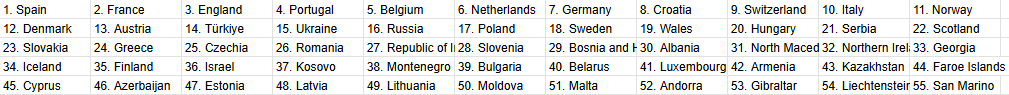

In [ ]:
while True:
  id_home_team=int(input("type a home team by its id : ")) - 1
  id_away_team=int(input("type a away team by its id : ")) + 54
  sample=np.zeros(110)
  sample[id_home_team]=1
  sample[id_away_team]=17
  sample=sample[:,None]
  if(model.predict(sample)==1): print("The home team wins")
  else:print("The away team tie or wins")

type a home team by its id : 1
type a away team by its id : 55
The away team tie or wins
